# Animal Swarm Classification: A Query Answering Machine
## QuAM Project — Data Preparation & Exploratory Data Analysis
**Team:** Iroda Ibrohimova · Madina Mirzatayeva · Amen Ghabara  
**Course:** 15-288 Machine Learning in a Nutshell, Spring 2026

---


### Problem Formulation (adressing feedback) ###
Following discussions with Prof. Gianni and Yusuf, we converged on the goal of classifying mammals in large aggregations from an aerial viewpoint. The primary use case is to support conservationists who rely on imagery from drones or static cameras to monitor groups of animals moving through various environments. While existing machine learning models perform well at detecting and classifying individual animals, there is a gap in the literature when it comes to classification in scenarios where large numbers of animals appear together in a single frame. This is a common real-world challenge for conservationists, as many mammal species naturally move in herds or groups, and in dense or complex environments, occlusion, overlap, and visual clutter make species-level identification significantly harder.
Our work addresses this gap directly. During our data collection phase, we found that purely aerial images of mammals in large aggregations are relatively scarce. To address this, we scraped and labeled both side-view and aerial images, maximizing the total number of images to ensure our model is robust enough to classify the six selected mammal species in noisy, complex environments.

## Loading the dataset ##

In [10]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import cv2
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
import imagehash

warnings.filterwarnings('ignore')

DATASET_DIR = Path("dataset")
CLASSES = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print(f"Classes found ({len(CLASSES)}): {CLASSES}")

PALETTE = {
    'Buffalo': '#C0392B', 'Elephant': '#7F8C8D',
    'Hoofed Grazers': '#27AE60', 'Musk Ox': '#8E44AD',
    'Wildebeest': '#E67E22', 'Zebra': '#2C3E50',
}
COLOR_LIST = [PALETTE.get(c, '#3498DB') for c in CLASSES]
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120})

Classes found (6): ['Buffalo', 'Elephant', 'Hoofed Grazers', 'Musk Ox', 'Wildebeest', 'Zebra']


In [12]:
VALID_EXTS = {'.jpg'}

records = []
for cls in CLASSES:
    cls_dir = DATASET_DIR / cls
    for fpath in cls_dir.iterdir():
        if fpath.suffix.lower() not in VALID_EXTS:
            continue
        try:
            with Image.open(fpath) as img:
                w, h = img.size
                mode = img.mode
                arr = np.array(img.convert('RGB'))
                brightness = float(arr.mean())
                contrast   = float(arr.std())
                gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
                sharpness  = float(cv2.Laplacian(gray, cv2.CV_64F).var())
                file_kb    = fpath.stat().st_size / 1024
            records.append(dict(
                filepath=str(fpath),
                label=cls,
                width=w, height=h,
                aspect_ratio=round(w/h, 3),
                mode=mode,
                brightness=round(brightness, 2),
                contrast=round(contrast, 2),
                sharpness=round(sharpness, 2),
                file_kb=round(file_kb, 2),
                is_rgb=(mode == 'RGB'),
            ))
        except Exception as e:
            print(f"  [SKIP] {fpath.name}: {e}")

df = pd.DataFrame(records)
print(f"Total images loaded: {len(df)}")
df.head()

Total images loaded: 5920


,filepath,label,width,height,aspect_ratio,mode,brightness,contrast,sharpness,file_kb,is_rgb
0,dataset/Buffalo/Buffalo_0213.jpg,Buffalo,640,640,1.0,RGB,126.13,55.88,63.60,81.35,True
1,dataset/Buffalo/Buffalo_0575.jpg,Buffalo,640,640,1.0,RGB,101.34,51.13,163.54,104.64,True
2,dataset/Buffalo/Buffalo_0561.jpg,Buffalo,640,640,1.0,RGB,129.26,53.70,288.66,118.82,True
3,dataset/Buffalo/Buffalo_0207.jpg,Buffalo,640,640,1.0,RGB,123.56,76.50,124.72,90.74,True
4,dataset/Buffalo/Buffalo_0549.jpg,Buffalo,640,640,1.0,RGB,135.62,57.77,102.23,81.20,True


## D2.1: Data Acquisition – Finding, Scraping, or Generating Data ##


### 1.1 Overview

Initial data collection was done by scraping DuckDuckGo Image Search using
Selenium (`scrape_6_groups.py`, submitted separately), targeting 6 mammal herd
classes with multiple search queries per class (e.g. *"zebra herd aerial view"*,
*"wildebeest migration thousands"*). This produced a raw URL list saved to
`animal_groups_urls.csv`.

Once the raw data was collected, it quickly became clear that it was **not ready
for analysis**. Images were inconsistent: many showed individual animals rather
than herds, some were cartoons or diagrams, and others were completely
irrelevant to the task. On top of that, images came in different formats, sizes,
and many had watermark bars at the bottom. Running EDA on data in this state
would have produced misleading results, so we decided to do a **pre-EDA
cleaning phase** before any analysis.

This pre-EDA cleaning happened in two steps:

**Step 1 — Manual Visual Review** (`image_cleaner_v2.py`, submitted separately):
We built a lightweight local web interface that loaded images in batches of 20,
allowing each team member to click through and keep or reject images for their
assigned classes. Rejection criteria included: irrelevant objects or aimals,
cartoons or diagrams, heavily watermarked images, and ambiguous species. While
the decisions were manual, the interface automated the loading, batching, and
saving, significantly speeding up the process. Per-class `cleaned_*.csv` files
and rejection reports were saved automatically.

**Step 2 — Format Standardisation** (`prepare_dataset.ipynb`): Once clean URL
lists were ready, all kept images were downloaded in parallel using 16 threads.
Each image was converted to RGB to ensure a consistent 3-channel format. Before
resizing, the bottom 8% of each image was cropped to remove watermark bars
consistently present in scraped web images. Images were then centre-cropped and
resized to a uniform **640×640 JPEG**.This resolution was chosen because future training
plans include YOLO-based models, which natively operate at 640x640.
Collecting at this resolution avoids any upscaling artifacts later.
For models that require smaller inputs (such as ResNet50 at 224x224),
downscaling from 640x640 is straightforward and lossless in practice,
whereas upscaling from a smaller resolution would degrade image quality.Any URLs that failed to download were
logged to `failed_downloads.csv` for inspection.

> **Important Note:** These pre-EDA cleaning steps were necessary because the
> raw scraped data had structural issues, inconsistent resolutions, mixed
> formats, and watermarks, that would have distorted basic EDA metrics like
> brightness, contrast, and channel distributions. By resolving these first, we
> ensure that the EDA in the next chapter reflects the actual content of the
> images rather than artefacts of the collection process.


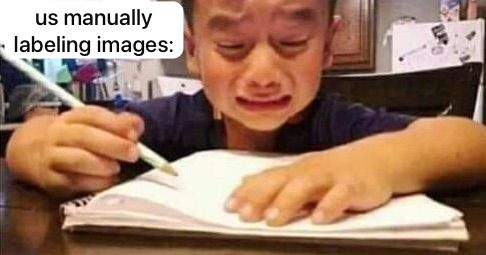

In [2]:
import base64
from IPython.display import HTML

with open('fun_mem.jpeg', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode('utf-8')

HTML(f'<img src="data:image/png;base64,{img_data}" style="width:80%;"/>')

In [39]:
acquisition_data = {
    'Buffalo':        {'scraped': 1775, 'kept': 656},
    'Elephant':       {'scraped': 2304, 'kept': 958},
    'Hoofed Grazers': {'scraped': 2720, 'kept': 1485},
    'Musk Ox':        {'scraped': 1214, 'kept': 983},
    'Wildebeest':     {'scraped': 2158, 'kept': 1214},
    'Zebra':          {'scraped': 2237, 'kept': 630},
}
acq_df = pd.DataFrame(acquisition_data).T
acq_df['rejected']       = acq_df['scraped'] - acq_df['kept']
acq_df['rejection_rate'] = (acq_df['rejected'] / acq_df['scraped'] * 100).round(1)

print("=" * 55)
print(f"{'Class':<18} {'Scraped':>8} {'Kept':>8} {'Rejected':>9} {'Rej%':>6}")
print("=" * 55)
for cls, row in acq_df.iterrows():
    print(f"{cls:<18} {int(row['scraped']):>8} {int(row['kept']):>8} "
          f"{int(row['rejected']):>9} {row['rejection_rate']:>5.1f}%")
print("=" * 55)
print(f"{'TOTAL':<18} {int(acq_df['scraped'].sum()):>8} "
      f"{int(acq_df['kept'].sum()):>8} "
      f"{int(acq_df['rejected'].sum()):>9} "
      f"{acq_df['rejected'].sum()/acq_df['scraped'].sum()*100:>5.1f}%")

Class               Scraped     Kept  Rejected   Rej%
Buffalo                1775      656      1119  63.0%
Elephant               2304      958      1346  58.4%
Hoofed Grazers         2720     1485      1235  45.4%
Musk Ox                1214      983       231  19.0%
Wildebeest             2158     1214       944  43.7%
Zebra                  2237      630      1607  71.8%
TOTAL                 12408     5926      6482  52.2%


> **Note:** The total scraped count was 12,408 URLs. After manual visual review, 
> 5,926 URLs were retained. The final downloaded dataset is smaller still, 
> as some URLs returned HTTP errors or corrupted files during download — 
> these were logged to `failed_downloads.csv`.

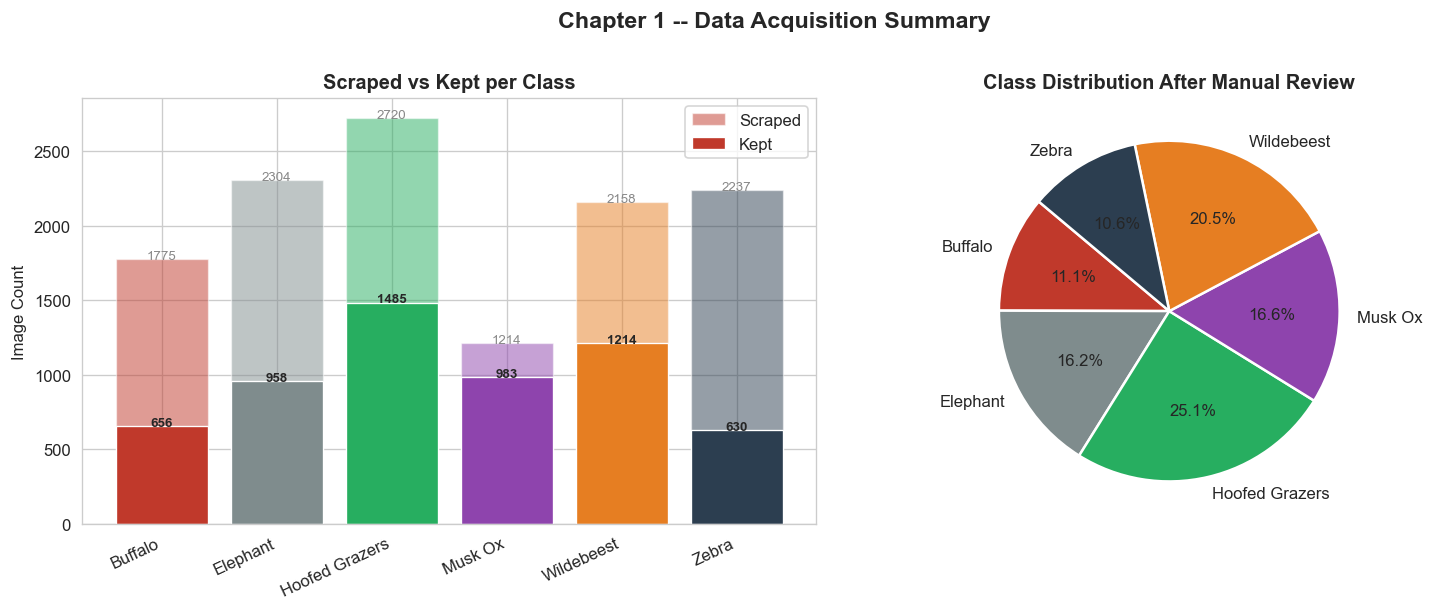

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(CLASSES))
colors = [PALETTE[c] for c in CLASSES]

# Left -- scraped vs kept
axes[0].bar(x, acq_df.loc[CLASSES, 'scraped'], color=colors, alpha=0.5,
            edgecolor='white', linewidth=0.8, label='Scraped')
axes[0].bar(x, acq_df.loc[CLASSES, 'kept'], color=colors, alpha=1.0,
            edgecolor='white', linewidth=0.8, label='Kept')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASSES, rotation=25, ha='right')
axes[0].set_title('Scraped vs Kept per Class', fontweight='bold')
axes[0].set_ylabel('Image Count')
axes[0].legend()
for i, (sc, kp) in enumerate(zip(acq_df.loc[CLASSES, 'scraped'],
                                   acq_df.loc[CLASSES, 'kept'])):
    axes[0].text(i, sc + 2, str(int(sc)), ha='center', fontsize=8, color='#888')
    axes[0].text(i, kp + 2, str(int(kp)), ha='center', fontsize=8, fontweight='bold')

# Right -- final kept distribution (balance check)
kept_vals = acq_df.loc[CLASSES, 'kept']
axes[1].pie(kept_vals, labels=CLASSES, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution After Manual Review', fontweight='bold')

plt.suptitle('Chapter 1 -- Data Acquisition Summary', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Observations

- After manual review, the dataset retained approximately **50%** of scraped URLs on average.
- The most common rejection reasons were: non-mammal or irrevelant objects on the photos, individual animals (not herds), watermarked/logo-heavy stock photos, and ambiguous species.
- All retained images were standardized to **640×640 RGB JPEG** with the bottom 8% cropped to remove watermark bars before resizing.


## D2.2: Data Analysis ##

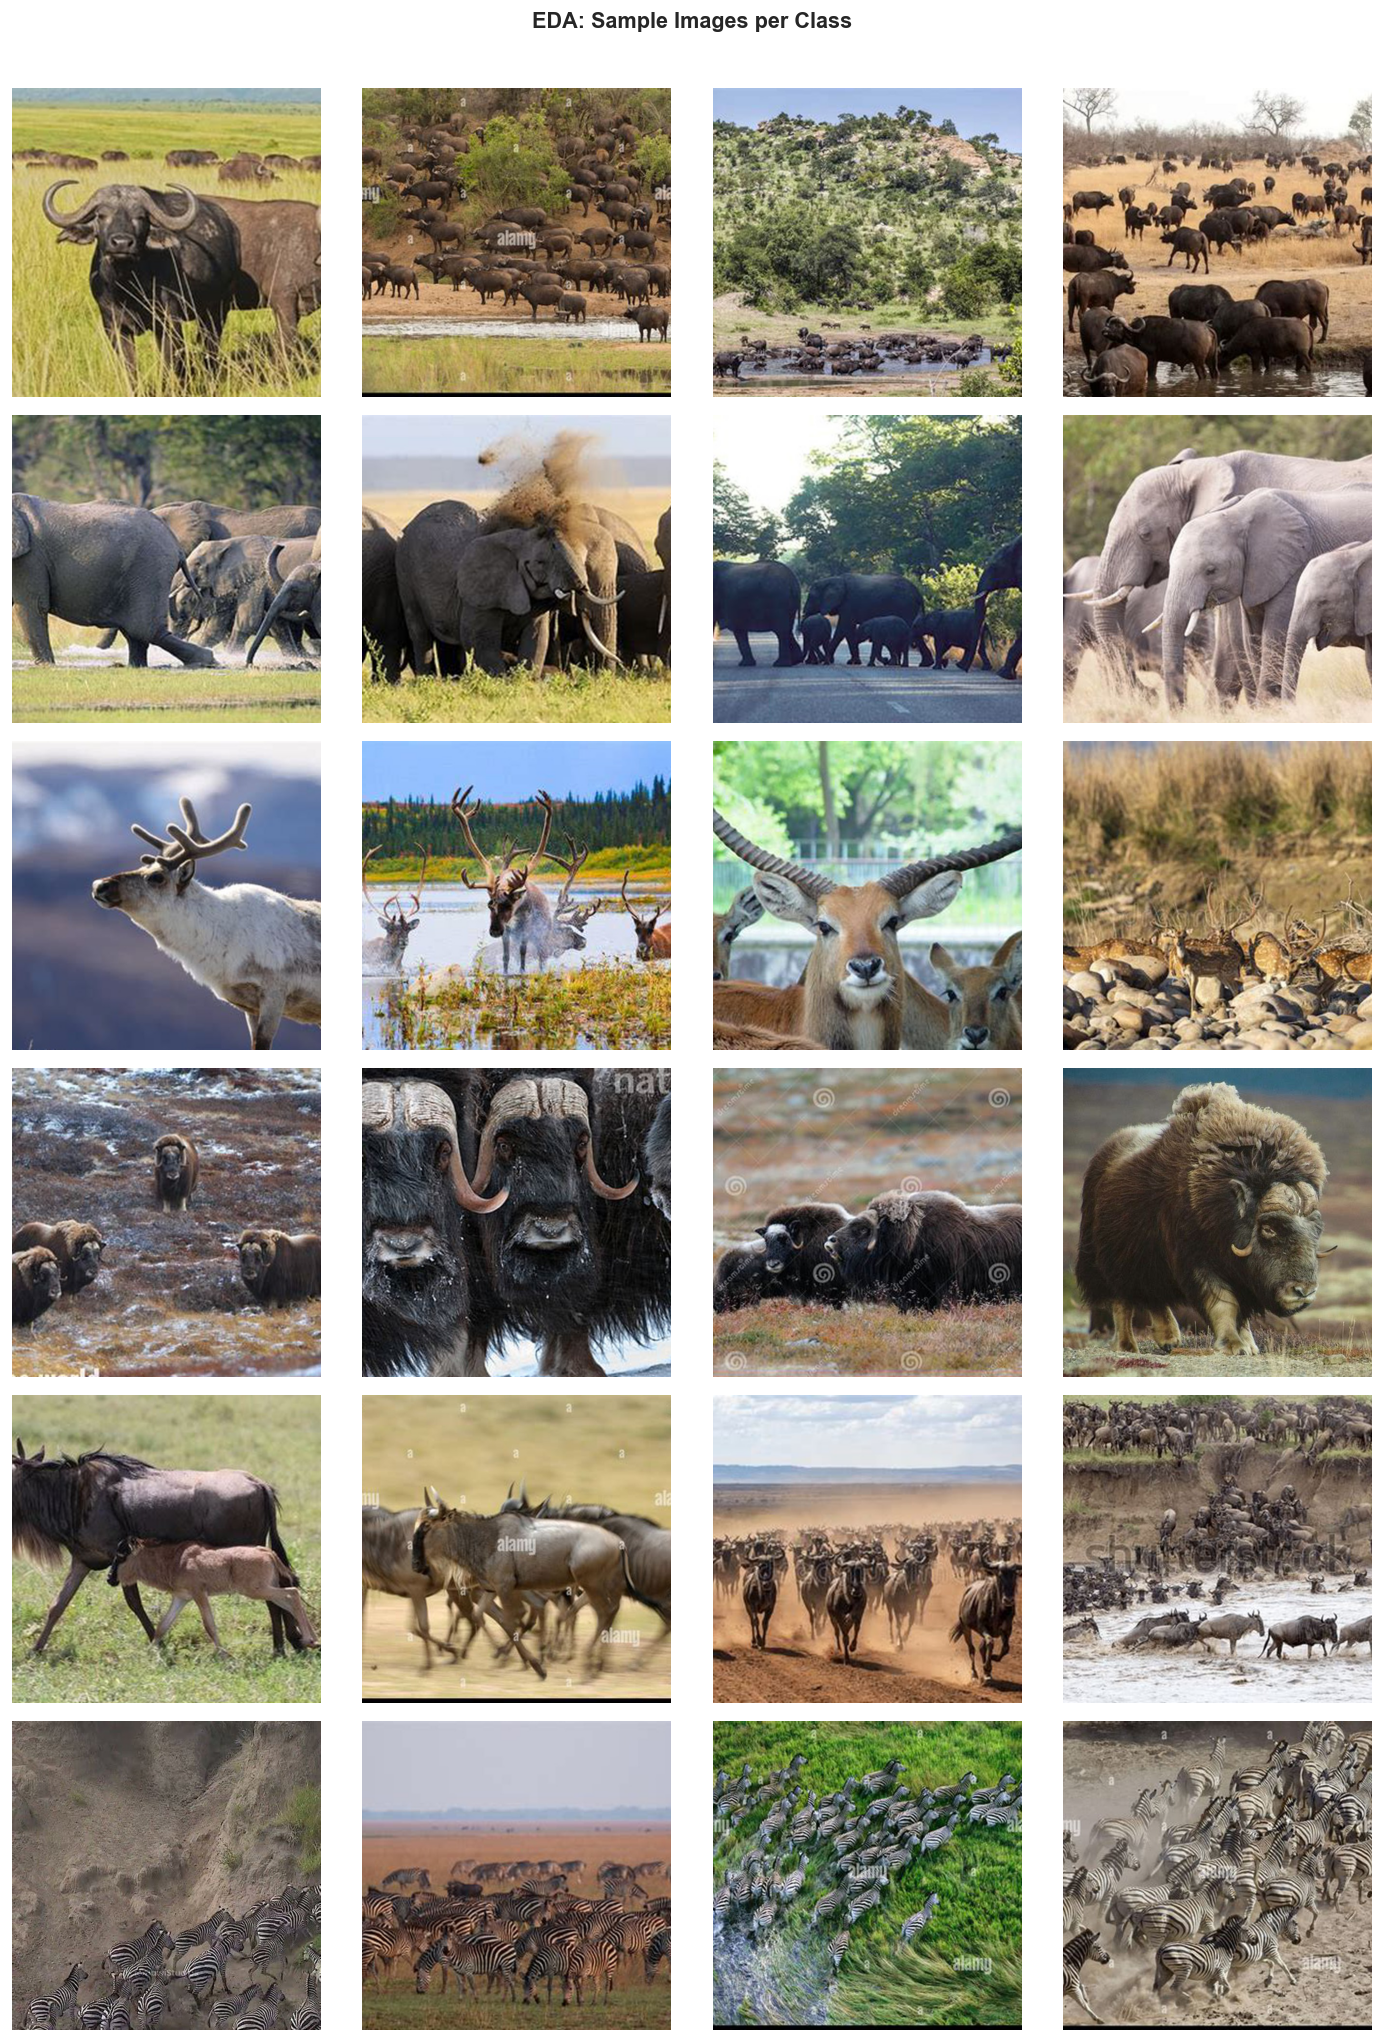

In [128]:
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(12, len(CLASSES) * 2.8))

for row, cls in enumerate(CLASSES):
    files = [f for f in (DATASET_DIR/cls).iterdir()
             if f.suffix.lower() in VALID_EXTS][:4]
    for col in range(4):
        ax = axes[row, col]
        if col < len(files):
            try:
                ax.imshow(Image.open(files[col]).convert('RGB'))
            except: pass
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold',
                          rotation=90, labelpad=5, va='center')

plt.suptitle('EDA: Sample Images per Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [45]:

print("Wrangling — Detecting Issues")


# Non-RGB 
non_rgb = df[~df['is_rgb']]
print(f"\n[1] Non-RGB images              : {len(non_rgb)}")
if len(non_rgb) > 0:
    print(non_rgb[['filepath','label','mode']].to_string())

# Blurry images
BLUR_THRESH = 10.0
blurry = df[df['sharpness'] < BLUR_THRESH]
print(f"[2] Blurry (sharpness < {BLUR_THRESH})   : {len(blurry)}")
print(f"    Sharpness range: [{df['sharpness'].min():.1f}, {df['sharpness'].max():.1f}]")

# Brightness outliers
B_LOW, B_HIGH = 30, 225
dark   = df[df['brightness'] < B_LOW]
bright = df[df['brightness'] > B_HIGH]
print(f"[3] Too dark  (brightness < {B_LOW})   : {len(dark)}")
print(f"    Too bright (brightness > {B_HIGH}) : {len(bright)}")

# Summary
print(f"\n    Total flagged : {len(non_rgb) + len(blurry) + len(dark) + len(bright)}")
print(f"    Dataset size  : {len(df)}")

Wrangling — Detecting Issues

[1] Non-RGB images              : 0
[2] Blurry (sharpness < 10.0)   : 62
    Sharpness range: [1.7, 4795.3]
[3] Too dark  (brightness < 30)   : 2
    Too bright (brightness > 225) : 10

    Total flagged : 74
    Dataset size  : 5920


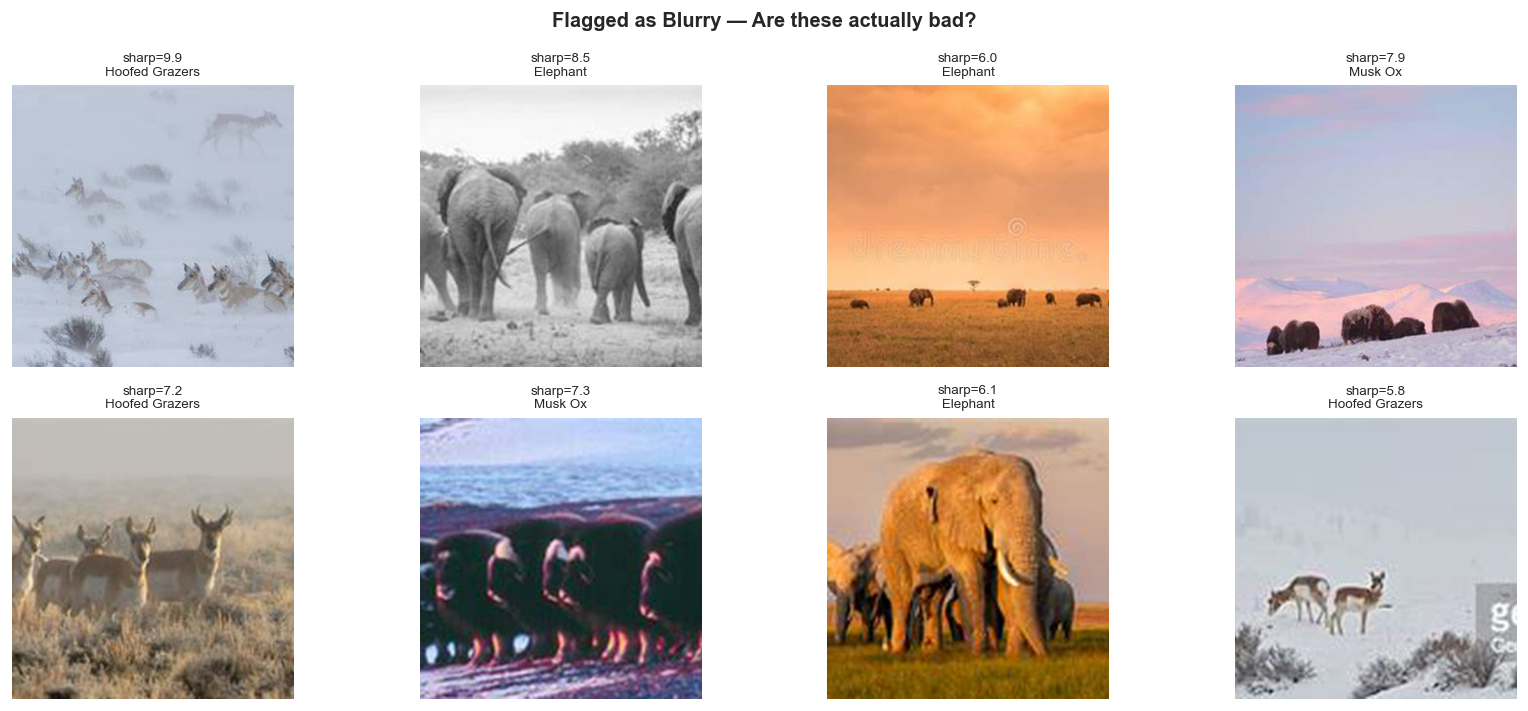

In [91]:
# Sample of some "blurry" images to see if threshold is right
blurry_samples = df[df['sharpness'] < BLUR_THRESH].sample(min(8, len(blurry)))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (_, row) in zip(axes.flatten(), blurry_samples.iterrows()):
    try:
        ax.imshow(Image.open(row['filepath']))
        ax.set_title(f"sharp={row['sharpness']:.1f}\n{row['label']}", fontsize=8)
    except: pass
    ax.axis('off')
plt.suptitle('Flagged as Blurry — Are these actually bad?', fontweight='bold')
plt.tight_layout()
plt.show()

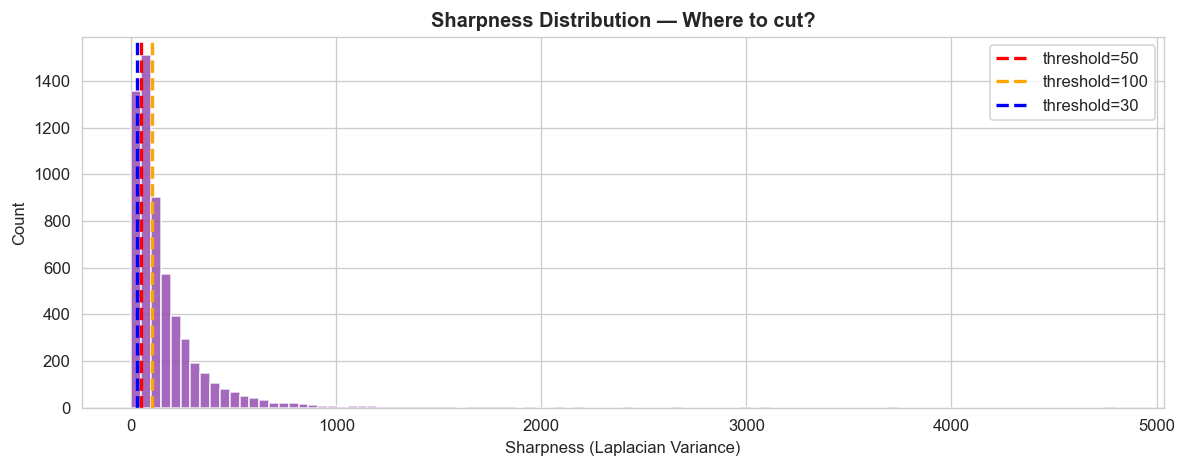

  threshold=  20  →  removes   292  (4.9%)
  threshold=  30  →  removes   656  (11.1%)
  threshold=  50  →  removes  1362  (23.0%)
  threshold=  75  →  removes  2254  (38.1%)
  threshold= 100  →  removes  2916  (49.3%)


In [73]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['sharpness'], bins=100, color='#8E44AD', alpha=0.8, edgecolor='white')
ax.axvline(50,  color='red',    linestyle='--', linewidth=2, label='threshold=50')
ax.axvline(100, color='orange', linestyle='--', linewidth=2, label='threshold=100')
ax.axvline(30,  color='blue',   linestyle='--', linewidth=2, label='threshold=30')
ax.set_xlabel('Sharpness (Laplacian Variance)')
ax.set_ylabel('Count')
ax.set_title('Sharpness Distribution — Where to cut?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# How many removed at different thresholds
for t in [20, 30, 50, 75, 100]:
    n = (df['sharpness'] < t).sum()
    print(f"  threshold={t:>4}  →  removes {n:>5}  ({100*n/len(df):.1f}%)")

**Blur Threshold Justification:** The sharpness distribution is heavily
right-skewed with no natural separation point, which is expected for herd
images, dense crowds, animal movement, and aerial perspectives all
inherently reduce Laplacian variance compared to single-animal photography.
Applying an aggressive threshold would remove valid herd images simply
because they depict natural motion. We therefore use a conservative
threshold of **10**, targeting only images at the extreme low end that
are genuinely unusable. The remaining flagged images at higher thresholds
are retained as they represent legitimate visual characteristics of
herd photography rather than image quality failures.

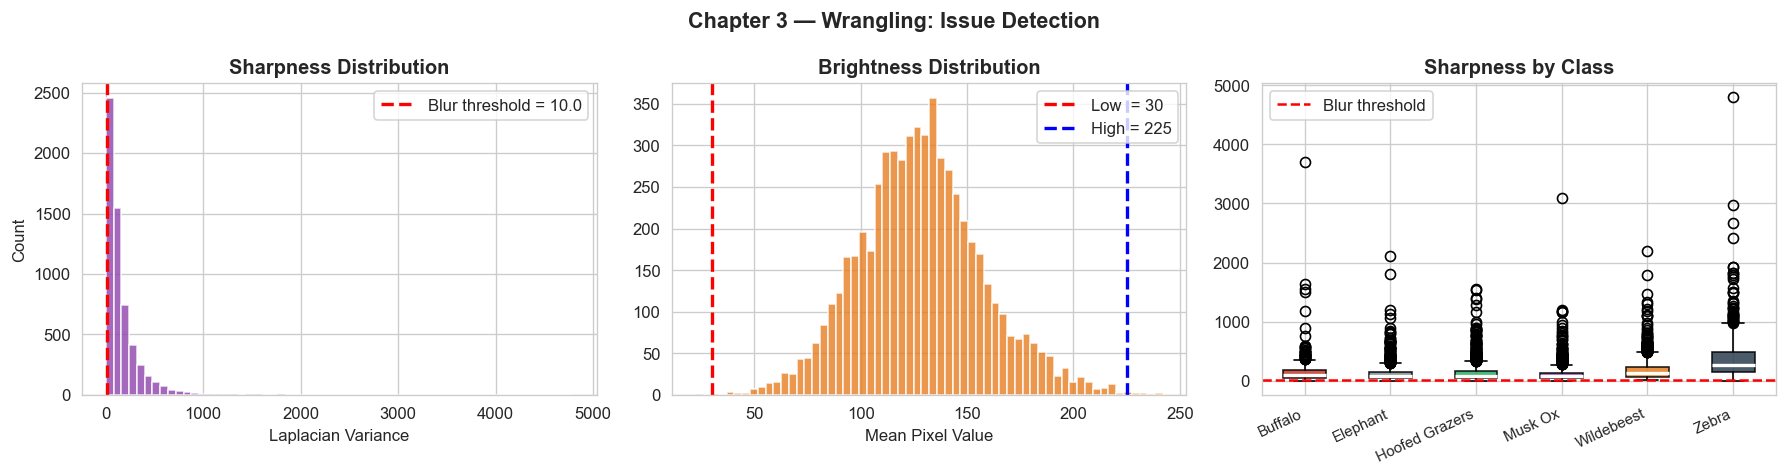

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sharpness distribution with threshold line
axes[0].hist(df['sharpness'], bins=60, color='#8E44AD', alpha=0.8, edgecolor='white')
axes[0].axvline(BLUR_THRESH, color='red', linewidth=2, linestyle='--',
                label=f'Blur threshold = {BLUR_THRESH}')
axes[0].set_title('Sharpness Distribution', fontweight='bold')
axes[0].set_xlabel('Laplacian Variance')
axes[0].set_ylabel('Count')
axes[0].legend()

# Brightness distribution with threshold lines
axes[1].hist(df['brightness'], bins=60, color='#E67E22', alpha=0.8, edgecolor='white')
axes[1].axvline(B_LOW,  color='red', linewidth=2, linestyle='--',
                label=f'Low  = {B_LOW}')
axes[1].axvline(B_HIGH, color='blue', linewidth=2, linestyle='--',
                label=f'High = {B_HIGH}')
axes[1].set_title('Brightness Distribution', fontweight='bold')
axes[1].set_xlabel('Mean Pixel Value')
axes[1].legend()

# Per-class sharpness boxplot
data = [df[df['label'] == cls]['sharpness'].values for cls in CLASSES]
bp = axes[2].boxplot(data, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, cls in zip(bp['boxes'], CLASSES):
    patch.set_facecolor(PALETTE[cls])
    patch.set_alpha(0.85)
axes[2].axhline(BLUR_THRESH, color='red', linewidth=1.5,
                linestyle='--', label=f'Blur threshold')
axes[2].set_xticks(range(1, len(CLASSES)+1))
axes[2].set_xticklabels(CLASSES, rotation=25, ha='right', fontsize=9)
axes[2].set_title('Sharpness by Class', fontweight='bold')
axes[2].legend()

plt.suptitle('Chapter 3 — Wrangling: Issue Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Sharpness, Bluriness and Brightness ###
**Non-RGB images:** 0 found. Expected, since prepare_dataset.ipynb
already converted all images to RGB during download.

**Blur detection:** 62 images removed (1% of dataset). A threshold of
10 was selected after trials, keeping the removal rate minimal since
herd images are naturally lower in sharpness than single-animal images.
Looking at sharpness by class, Zebra shows the highest median due to
high-contrast black-and-white striping, while Buffalo and Wildebeest
sit lower reflecting their darker, more uniform coats. Importantly,
all class medians sit well above the threshold of 10, confirming that
the threshold does not disproportionately affect any single class.

**Brightness outliers:** 12 images removed, 2 near-black and 10
overexposed. Isolated cases consistent with the healthy brightness
distribution seen in EDA.



In [82]:
print("Computing perceptual hashes for duplicate detection...")
print("(may take a few minutes on large datasets)\n")

def dhash(img, hash_size=8):
    img = img.convert('L').resize((hash_size + 1, hash_size), Image.LANCZOS)
    arr = np.array(img)
    return (arr[:, 1:] > arr[:, :-1]).flatten().tobytes()

hash_map   = {}
duplicates = []

for _, row in df.iterrows():
    try:
        with Image.open(row['filepath']) as img:
            h = dhash(img)
        if h in hash_map:
            duplicates.append({
                'file_1': hash_map[h],
                'file_2': row['filepath'],
                'label':  row['label'],
            })
        else:
            hash_map[row['filepath']] = h
    except:
        pass

dup_df = pd.DataFrame(duplicates)
print(f"Near-duplicate pairs found: {len(dup_df)}")
if len(dup_df) > 0:
    print(f"\nBy class:")
    print(dup_df['label'].value_counts().to_string())

Computing perceptual hashes for duplicate detection...
(may take a few minutes on large datasets)

Near-duplicate pairs found: 0


### Duplicates ###
No near-duplicate pairs were found, meaning no need for cleaning the duplicates in later stages 

In [130]:
summary = df.groupby('label').agg(
    count        = ('filepath',   'count'),
    mean_bright  = ('brightness', 'mean'),
    std_bright   = ('brightness', 'std'),
    mean_contrast= ('contrast',   'mean'),
    mean_sharp   = ('sharpness',  'mean'),
    min_sharp    = ('sharpness',  'min'),
    file_kb_mean = ('file_kb',    'mean'),
).round(2)


print("EDA: Summary Statistics Table")

print(summary.to_string())

EDA: Summary Statistics Table
                count  mean_bright  std_bright  mean_contrast  mean_sharp  min_sharp  file_kb_mean
label                                                                                             
Buffalo           655       122.39       27.22          58.62      143.88       1.74         86.87
Elephant          957       124.49       26.06          58.58      129.43       5.45         82.11
Hoofed Grazers   1484       132.85       30.64          50.71      135.23       2.47         82.87
Musk Ox           982       131.99       35.61          61.26      121.86       2.50         75.33
Wildebeest       1213       127.27       24.90          55.64      185.39       9.06         92.60
Zebra             629       128.19       27.10          57.12      380.73       2.33        101.92


### Key observations from the summary statistics: ###

Zebra has by far the highest sharpness (380.73) due to high-contrast
black-and-white striping. Musk Ox shows the highest brightness
variation (std 35.61) reflecting dark coats against bright snowy
backgrounds. Hoofed Grazers is the brightest class on average (132.85)
consistent with open grassland environments.

## D2.3: Data Wrangling ##

In [83]:
df_clean = df.copy()


print("Wrangling -- Step-by-Step Removal Log")


n0 = len(df_clean)
print(f"  Starting count              : {n0}")

# Step 1: Remove non-RGB images
df_clean = df_clean[df_clean['is_rgb']]
n1 = len(df_clean)
print(f"  After non-RGB removal       : {n1}  (-{n0-n1})")

# Step 2: Remove blurry images (Laplacian variance < 10)
df_clean = df_clean[df_clean['sharpness'] >= BLUR_THRESH]
n2 = len(df_clean)
print(f"  After blur filter           : {n2}  (-{n1-n2})")

# Step 3: Remove brightness outliers
df_clean = df_clean[
    (df_clean['brightness'] >= B_LOW) &
    (df_clean['brightness'] <= B_HIGH)
]
n3 = len(df_clean)
print(f"  After brightness filter     : {n3}  (-{n2-n3})")

# Step 4: Remove near-duplicates (none found, step included for completeness)
if len(dup_df) > 0:
    dup_files = set(dup_df['file_2'].tolist())
    df_clean  = df_clean[~df_clean['filepath'].isin(dup_files)]
n4 = len(df_clean)
print(f"  After deduplication         : {n4}  (-{n3-n4})")


print(f"  Total removed               : {n0-n4}  ({100*(n0-n4)/n0:.1f}%)")
print(f"  Final clean count           : {n4}")
print("\nPer-class counts after wrangling:")
print(df_clean['label'].value_counts().reindex(CLASSES).to_string())

Wrangling -- Step-by-Step Removal Log
  Starting count              : 5920
  After non-RGB removal       : 5920  (-0)
  After blur filter           : 5858  (-62)
  After brightness filter     : 5846  (-12)
  After deduplication         : 5846  (-0)
  Total removed               : 74  (1.2%)
  Final clean count           : 5846

Per-class counts after wrangling:
label
Buffalo            648
Elephant           947
Hoofed Grazers    1456
Musk Ox            959
Wildebeest        1210
Zebra              626


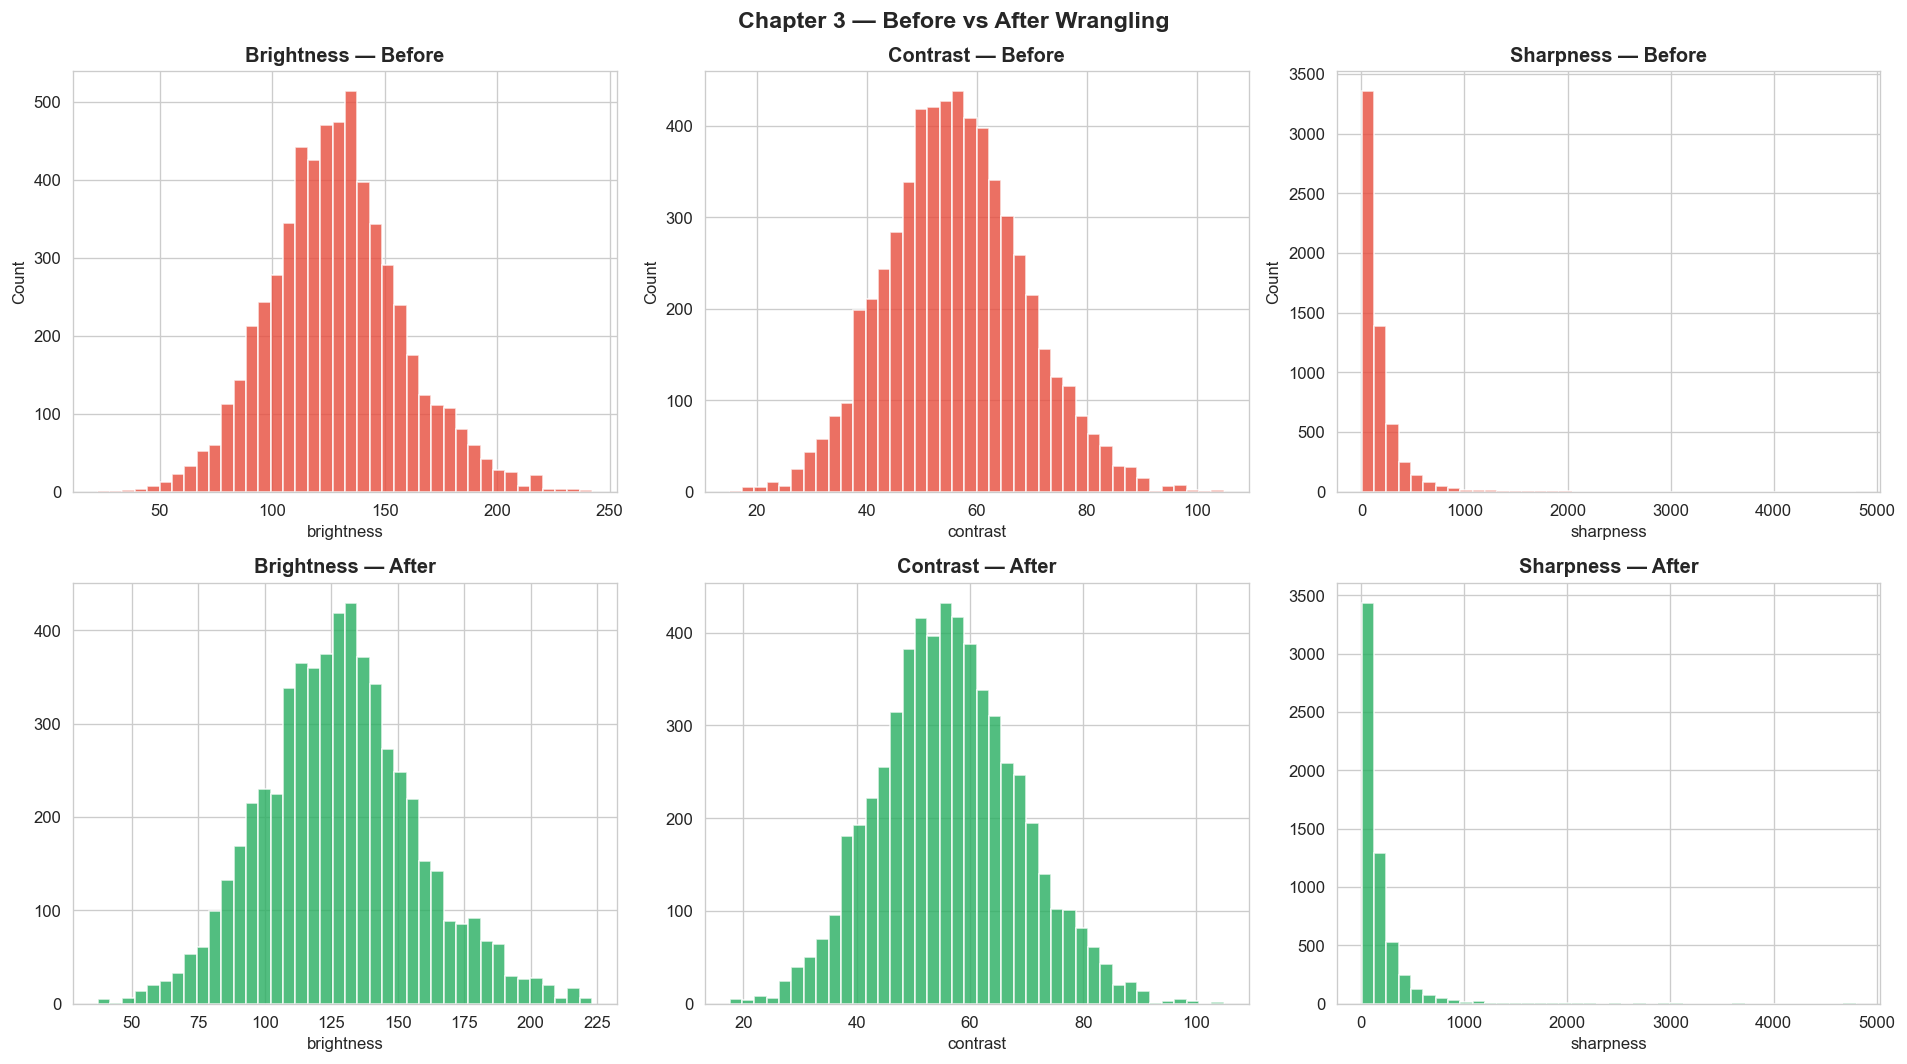

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = ['brightness', 'contrast', 'sharpness']

for col, metric in enumerate(metrics):
    # Before
    axes[0, col].hist(df[metric], bins=40,
                      color='#E74C3C', alpha=0.8, edgecolor='white')
    axes[0, col].set_title(f'{metric.capitalize()} — Before',
                            fontweight='bold')
    axes[0, col].set_xlabel(metric)
    axes[0, col].set_ylabel('Count')

    # After
    axes[1, col].hist(df_clean[metric], bins=40,
                      color='#27AE60', alpha=0.8, edgecolor='white')
    axes[1, col].set_title(f'{metric.capitalize()} — After',
                            fontweight='bold')
    axes[1, col].set_xlabel(metric)

plt.suptitle('Chapter 3 — Before vs After Wrangling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wrangling_before_after.png', bbox_inches='tight')
plt.show()

### After data wrangling: minimal change ###
The wrangling step removed 74 images in total, just 1.2% of the
dataset, bringing the final count to 5,846 images. The per-class
counts remain well-distributed with no class dropping significantly,
confirming that class balance was preserved throughout.

The before and after distributions for brightness, contrast, and
sharpness are nearly identical, which is expected given how few images
were removed. The brightness and contrast distributions remain
bell-shaped and centred in the same range. The sharpness distribution
retains its right-skewed shape with the only visible change being a
slight reduction at the very low end, which is precisely where the
blur filter was applied.


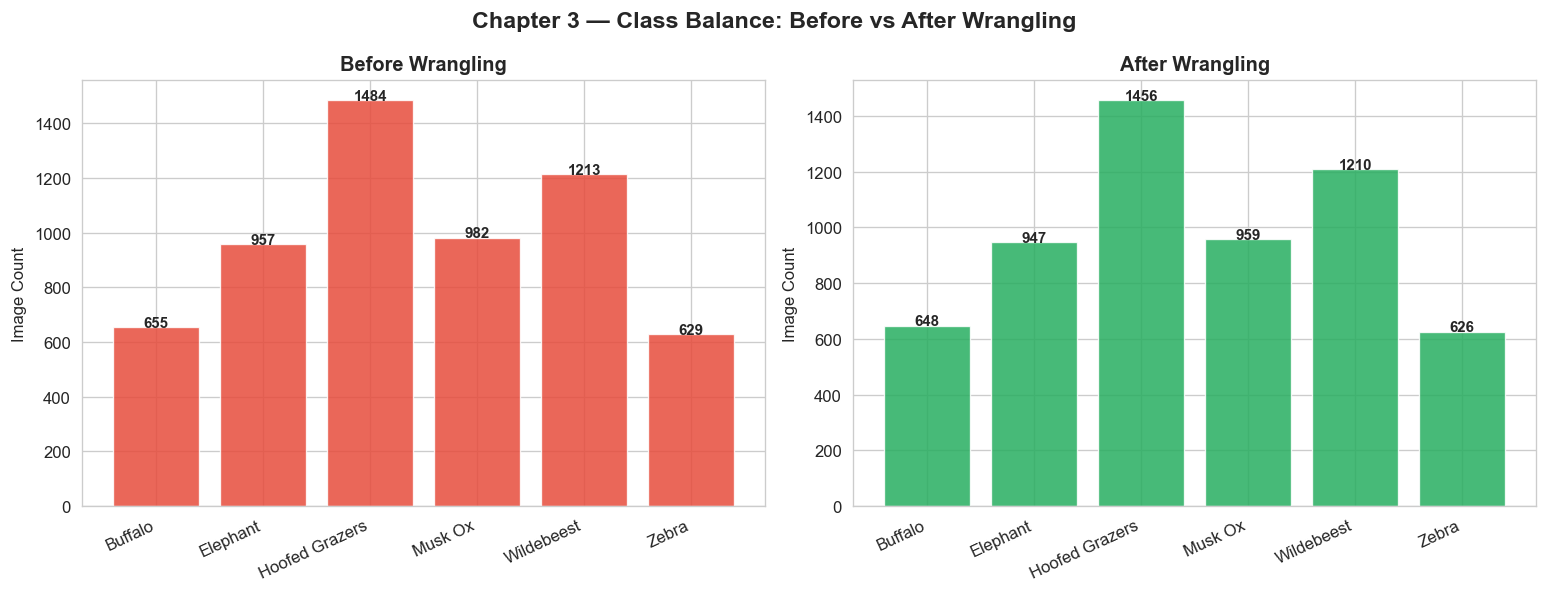

Imbalance ratio before : 2.36x
Imbalance ratio after  : 2.33x


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
before = df['label'].value_counts().reindex(CLASSES)
after  = df_clean['label'].value_counts().reindex(CLASSES).fillna(0)

for ax, counts, title, color in zip(
    axes,
    [before, after],
    ['Before Wrangling', 'After Wrangling'],
    ['#E74C3C', '#27AE60']
):
    ax.bar(counts.index, counts.values, color=color,
           alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_xticklabels(counts.index, rotation=25, ha='right')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Image Count')
    ax.set_xticks(range(len(CLASSES)))
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha='center',
                fontsize=9, fontweight='bold')

plt.suptitle('Chapter 3 — Class Balance: Before vs After Wrangling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wrangling_class_balance.png', bbox_inches='tight')
plt.show()

print(f"Imbalance ratio before : {before.max()/before.min():.2f}x")
print(f"Imbalance ratio after  : {after.max()/after.min():.2f}x")

### Class Imbalance ###

The class distribution remains consistent before and after wrangling,
confirming that the removal step did not introduce any new imbalance.
However, some imbalance between classes is visible: Hoofed Grazers
and Wildebeest have notably more images than Buffalo and Zebra, with
the gap reaching roughly 2.3x between the largest and smallest class.

This will be addressed in future steps either by collecting **additional
images through video frames** for underrepresented classes, or through **data
augmentation** techniques applied during training to synthetically
enrich minority classes.

## D2.4: Feature Engineering ##


### We can use CNN Feature Extraction with ResNet50
In class we learned that the layer just before the final output in a CNN contains 
all the rich features the network has learned. We remove that last layer and use 
the one before it as our feature extractor.

We use ResNet50 because it's already trained on ImageNet which includes animals — 
it already recognizes textures, shapes, and body patterns. Each image gets compressed 
into a 2048-number vector that captures high-level visual meaning, no training needed.

In [19]:
# !pip install keras jax jaxlib

In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import os
import numpy as np
import pandas as pd
import keras
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.utils import load_img, img_to_array

# Load ResNet50 without the classifier head
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

dataset_path = 'dataset'

features_list = []
labels_list = []
filenames_list = []

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_path):
        continue

    print(f"Processing: {class_name}")

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = load_img(img_path, target_size=(224, 224))
            img_array = img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = preprocess_input(img_array)

            feat = model.predict(img_array, verbose=0)

            features_list.append(feat.flatten())
            labels_list.append(class_name)
            filenames_list.append(img_name)

        except Exception as e:
            print(f"  Skipped {img_name}: {e}")

feature_cols = [f'feat_{i}' for i in range(2048)]
df = pd.DataFrame(features_list, columns=feature_cols)
df['label'] = labels_list
df['filename'] = filenames_list

print(f"\nFinal shape: {df.shape}")
print(df['label'].value_counts())

df.to_csv('cnn_features.csv', index=False)
print("Saved to cnn_features.csv")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 77s 1us/step
Processing: Buffalo
Processing: Elephant
Processing: Hoofed Grazers
Processing: Musk Ox
Processing: Wildebeest
Processing: Zebra

Final shape: (5870, 2050)
label
Hoofed Grazers    1465
Wildebeest        1193
Musk Ox            971
Elephant           957
Buffalo            655
Zebra              629
Name: count, dtype: int64
Saved to cnn_features.csv


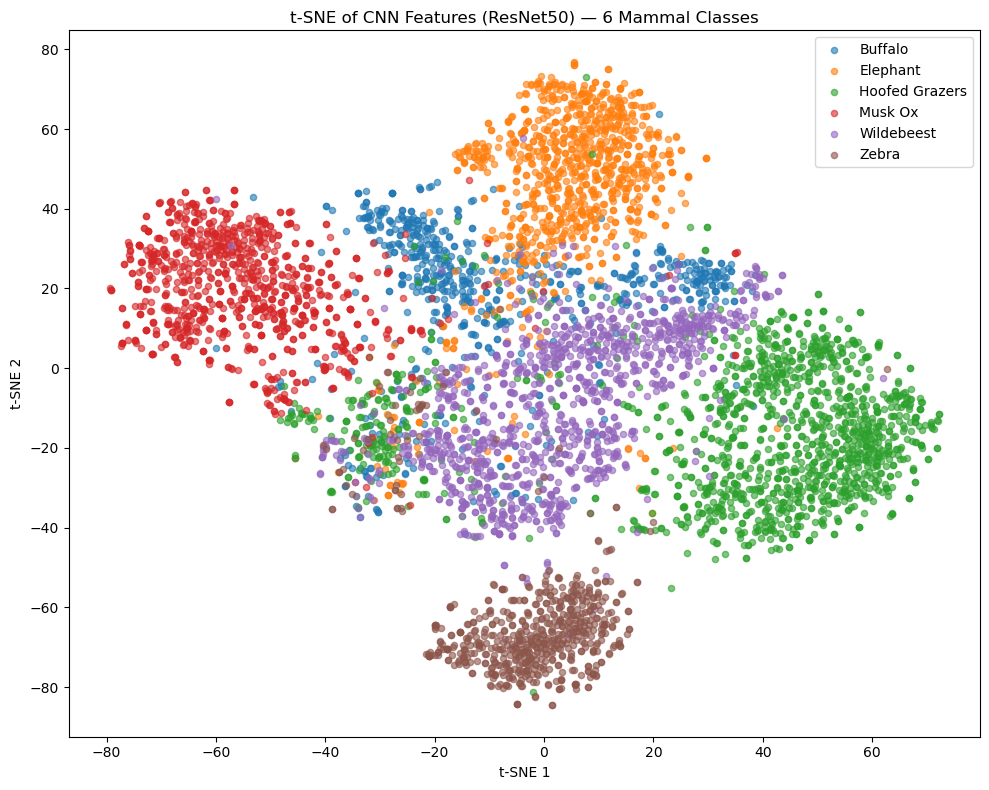

In [5]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

df = pd.read_csv('cnn_features.csv')

features = df.drop(columns=['label', 'filename']).values
labels = df['label'].values

# t-SNE reduction to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(10, 8))
for class_name in np.unique(labels):
    mask = labels == class_name
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                label=class_name, alpha=0.6, s=20)

plt.legend()
plt.title('t-SNE of CNN Features (ResNet50) — 6 Mammal Classes')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## t-SNE Visualization of CNN Features

The plot above shows our 5870 images projected from 2048 CNN features down to 2D using t-SNE. 
Each dot is one image, colored by its class label.

We can see that most classes form distinct clusters, meaning the ResNet50 features 
successfully capture visual differences between the mammal species. 

Some overlap exists between certain classes (e.g., Wildebeest and Buffalo regions touch), 
which makes sense since these animals share similar body shapes and appear in similar 
forest/grassland environments. 

The tight, well-separated cluster at the bottom (brown — likely Musk Ox or Elephant) 
suggests that class is visually very distinct from the others.

Overall, this confirms that our CNN feature extraction produces meaningful, 
class-discriminative features before any classifier is trained.

### We can also try HOG for feature extraction

In [28]:
 #!pip install scikit-image

In [1]:
import os
import numpy as np
import pandas as pd
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
from skimage.color import rgb2gray

dataset_path = 'dataset'

features_list = []
labels_list = []
filenames_list = []

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_path):
        continue

    print(f"Processing: {class_name}")

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = imread(img_path)
            img = resize(img, (128, 128))
            img_gray = rgb2gray(img)

            features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), feature_vector=True)

            features_list.append(features)
            labels_list.append(class_name)
            filenames_list.append(img_name)

        except Exception as e:
            print(f"  Skipped {img_name}: {e}")

feature_cols = [f'hog_{i}' for i in range(len(features_list[0]))]
df_hog = pd.DataFrame(features_list, columns=feature_cols)
df_hog['label'] = labels_list
df_hog['filename'] = filenames_list

print(f"\nFinal shape: {df_hog.shape}")
print(df_hog['label'].value_counts())

df_hog.to_csv('hog_features.csv', index=False)
print("Saved to hog_features.csv")

Processing: Buffalo
Processing: Elephant
Processing: Hoofed Grazers
Processing: Musk Ox
Processing: Wildebeest
Processing: Zebra

Final shape: (5870, 8102)
label
Hoofed Grazers    1465
Wildebeest        1193
Musk Ox            971
Elephant           957
Buffalo            655
Zebra              629
Name: count, dtype: int64
Saved to hog_features.csv


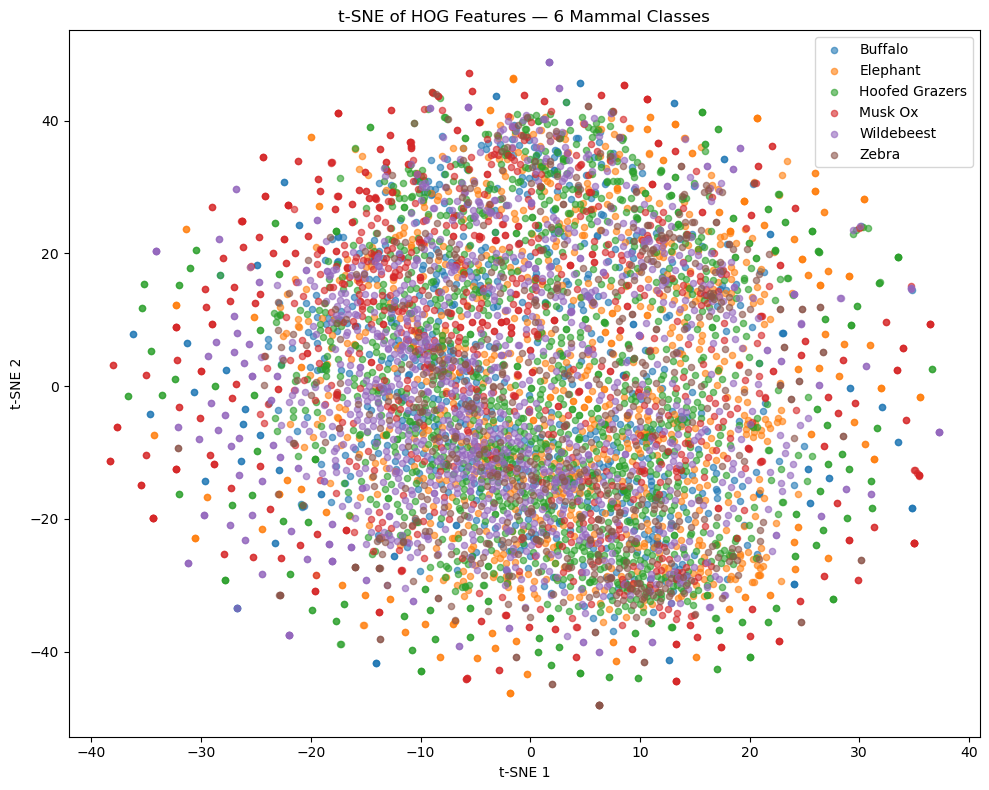

In [2]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

features = df_hog.drop(columns=['label', 'filename']).values
labels = df_hog['label'].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
for class_name in np.unique(labels):
    mask = labels == class_name
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                label=class_name, alpha=0.6, s=20)

plt.legend()
plt.title('t-SNE of HOG Features — 6 Mammal Classes')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

### HOG vs CNN Comparison

HOG features show no meaningful class separation — all classes overlap into one blob.
CNN features (ResNet50) produce clearly distinct clusters per class. 
This confirms CNN captures richer, more discriminative features for our task.

We proceed with CNN features as our final feature set.

### Standardization and Normalization

Normalization and standardization are handled at the appropriate stage
for each feature type rather than applied uniformly here.

For ResNet50 features, pixel-level normalization is handled
automatically by Keras via preprocess_input, which subtracts ImageNet
channel means before passing images through the network.

For HOG features, normalization is built into the descriptor itself
through L2 block normalization applied during extraction, so no
additional scaling is needed.

Any further standardization required for specific models, such as
before distance-based classifiers, will be applied at the modeling
stage where the exact feature inputs are known.


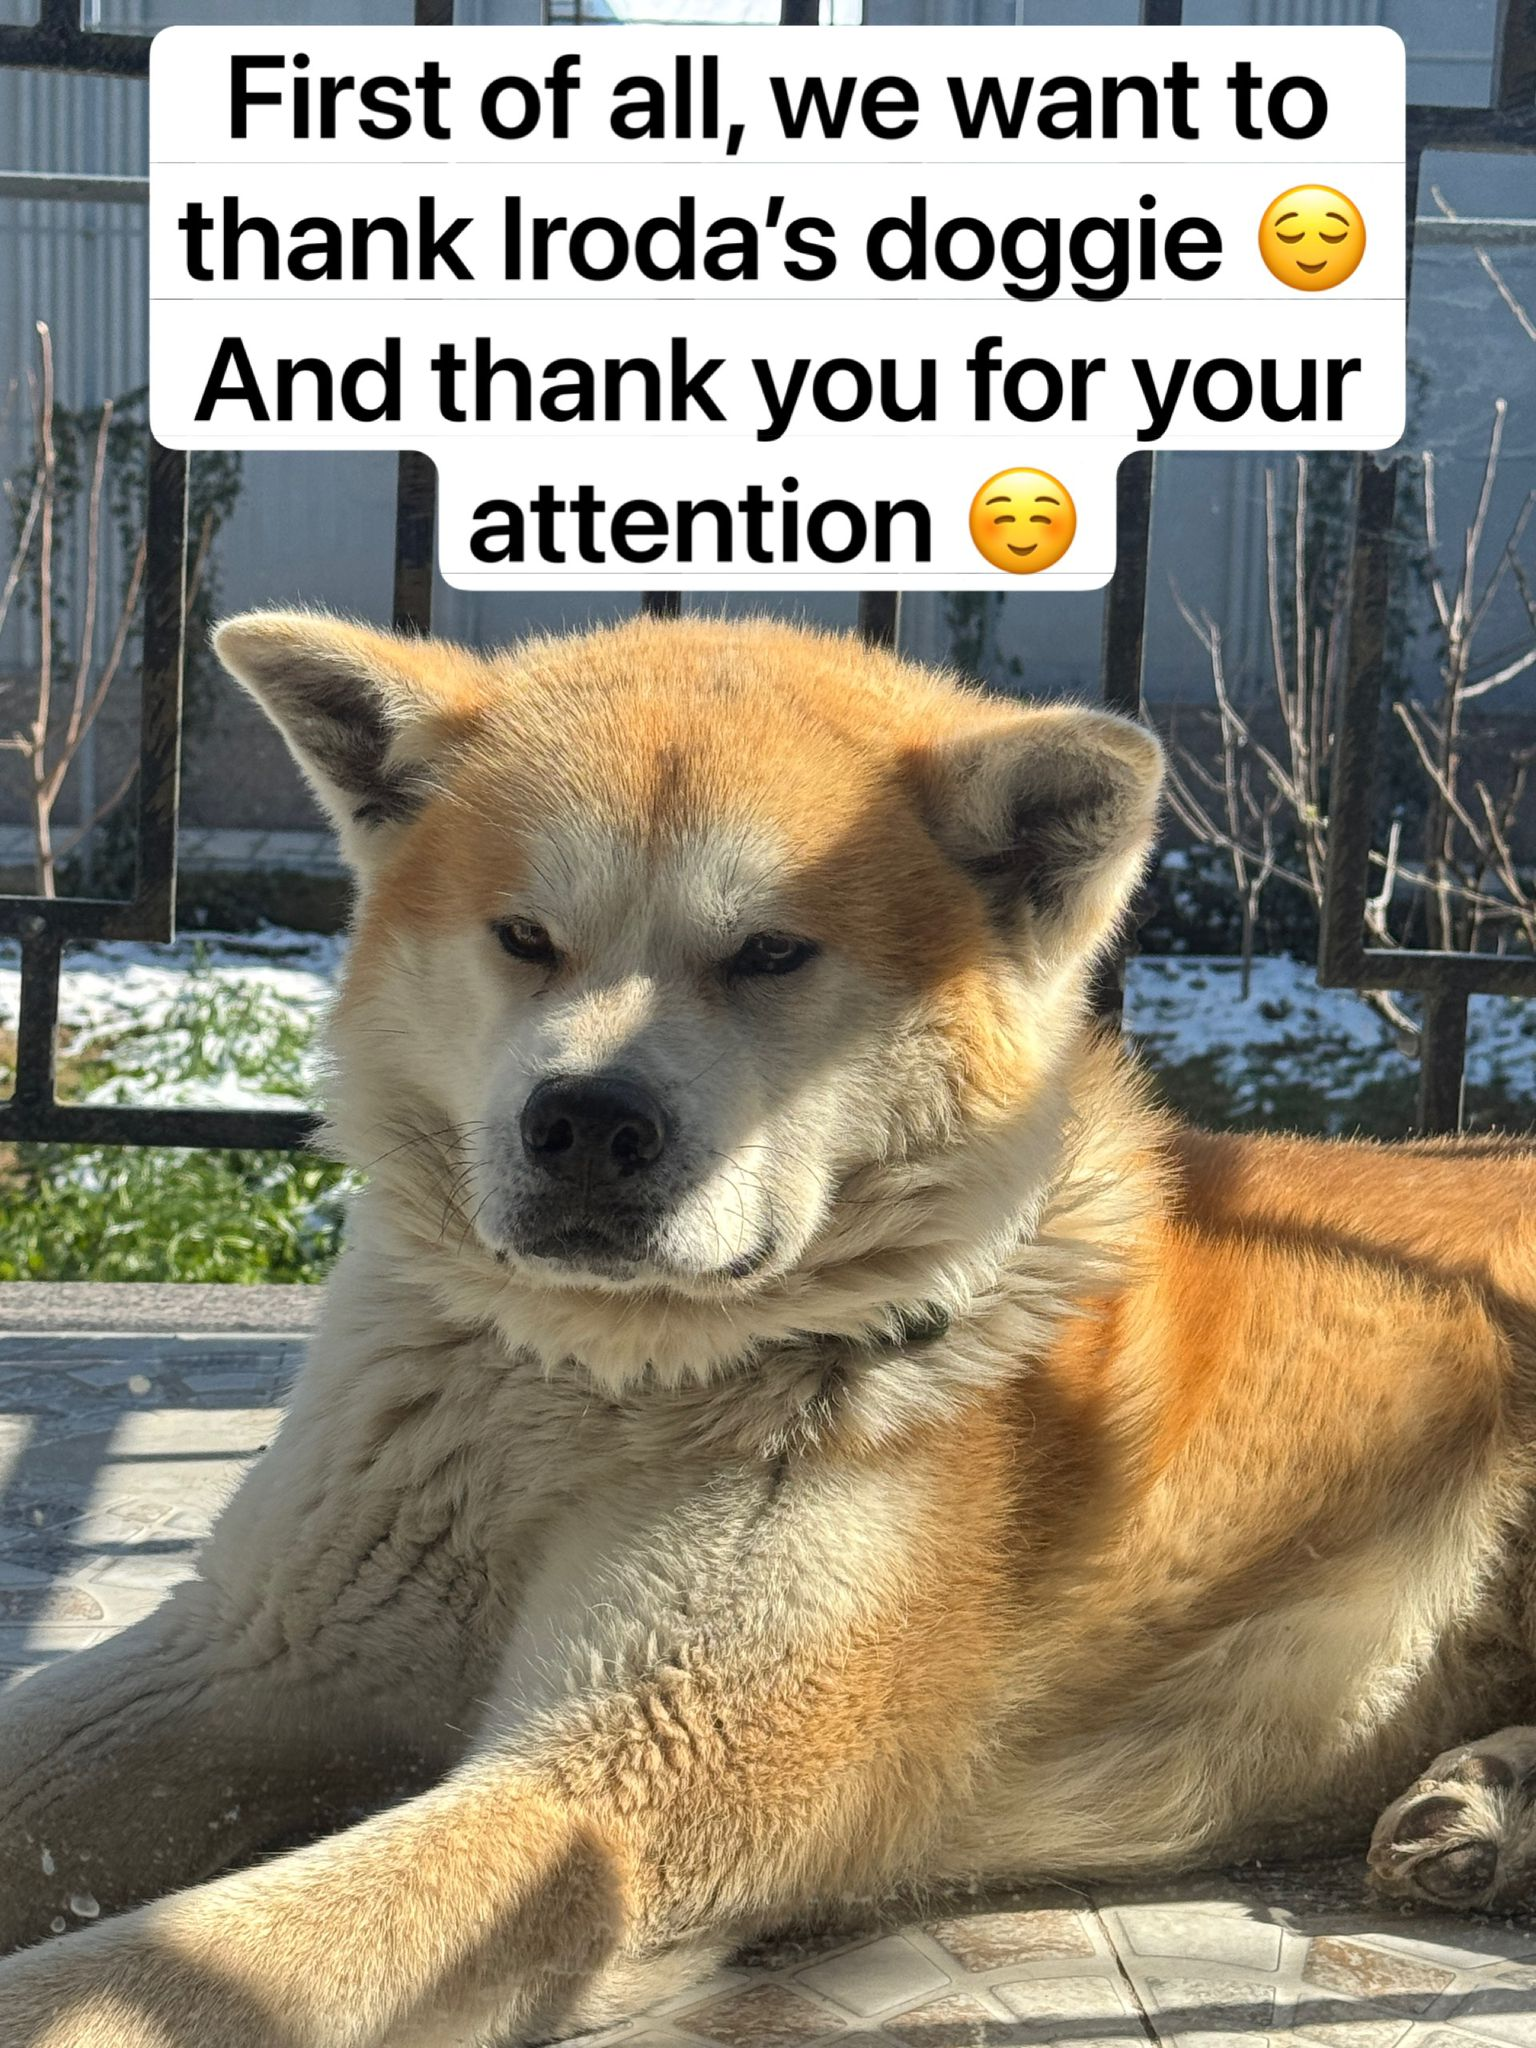

In [116]:
import base64
from IPython.display import HTML

with open('hati.jpeg', 'rb') as f:
    img_data = base64.b64encode(f.read()).decode('utf-8')

HTML(f'<img src="data:image/png;base64,{img_data}" style="width:70%;"/>')